In [1]:
from pathlib import Path
from urllib.parse import urlparse
from io import BytesIO
import hashlib
import json
import boto3
import pandas as pd

PROJECT_ROOT = Path.cwd()
config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

aws_session = boto3.Session(
    region_name=project_config["aws_region"]
)
s3_client = aws_session.client("s3")

feature_config = project_config["feature_store"]

def load_training_features(split_name):
    file_info = feature_config["datasets"][split_name]
    location = urlparse(file_info["uri"])

    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=file_info["version_id"]
    )
    try:
        content = response["Body"].read()
    finally:
        response["Body"].close()

    assert hashlib.sha256(content).hexdigest() == file_info["sha256"]

    df = pd.read_csv(
        BytesIO(content),
        dtype={"ticket_id": "string"},
        keep_default_na=False
    )
    assert len(df) == file_info["rows"]
    return df

train_df = load_training_features("train")
validation_df = load_training_features("validation")

MODEL_INPUT_COLUMNS = feature_config["model_input_columns"]
TARGET_COLUMN = feature_config["target_column"]

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Model inputs:", MODEL_INPUT_COLUMNS)

Training rows: 17710
Validation rows: 4428
Model inputs: ['combined_text', 'language', 'has_subject', 'subject_char_count', 'body_char_count', 'text_char_count', 'subject_word_count', 'body_word_count', 'text_word_count']


In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train = train_df[MODEL_INPUT_COLUMNS]
y_train = train_df[TARGET_COLUMN]

X_validation = validation_df[MODEL_INPUT_COLUMNS]
y_validation = validation_df[TARGET_COLUMN]

QUEUE_LABELS = sorted(y_train.unique())

# Learn only which queue is most common in the training set.
benchmark = DummyClassifier(strategy="most_frequent")
benchmark.fit(X_train, y_train)

benchmark_predictions = benchmark.predict(X_validation)

benchmark_metrics = {
    "model": "Majority-class benchmark",
    "evaluation_split": "validation",
    "accuracy": accuracy_score(
        y_validation, benchmark_predictions
    ),
    "macro_f1": f1_score(
        y_validation, benchmark_predictions,
        labels=QUEUE_LABELS, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_validation, benchmark_predictions,
        labels=QUEUE_LABELS, average="weighted", zero_division=0
    ),
}

print("Queue predicted for every ticket:", benchmark_predictions[0])
display(pd.DataFrame([benchmark_metrics]).round(4))

Queue predicted for every ticket: Technical Support


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,validation,0.2958,0.0457,0.1351


In [3]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=30000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            ),
            feature_config["text_column"]
        ),
        (
            "language",
            OneHotEncoder(handle_unknown="ignore"),
            feature_config["categorical_columns"]
        ),
        (
            "structural",
            StandardScaler(),
            feature_config["numeric_columns"]
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        C=1.0,
        random_state=42
    ))
])

print("Training Logistic Regression...", flush=True)
start_time = time.perf_counter()

lr_pipeline.fit(X_train, y_train)

training_seconds = time.perf_counter() - start_time
lr_predictions = lr_pipeline.predict(X_validation)

lr_metrics = {
    "model": "TF-IDF + metadata + Logistic Regression",
    "evaluation_split": "validation",
    "accuracy": accuracy_score(y_validation, lr_predictions),
    "macro_f1": f1_score(
        y_validation, lr_predictions,
        labels=QUEUE_LABELS, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_validation, lr_predictions,
        labels=QUEUE_LABELS, average="weighted", zero_division=0
    ),
}

print(f"Training time: {training_seconds:.1f} seconds")
print("Solver iterations:", lr_pipeline["classifier"].n_iter_)
display(pd.DataFrame([benchmark_metrics, lr_metrics]).round(4))

Training Logistic Regression...
Training time: 17.3 seconds
Solver iterations: [216]


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,validation,0.2958,0.0457,0.1351
1,TF-IDF + metadata + Logistic Regression,validation,0.3850,0.3623,0.3890


In [4]:
from sklearn.metrics import classification_report

# Performance for each of the 10 queues.
queue_report = classification_report(
    y_validation,
    lr_predictions,
    labels=QUEUE_LABELS,
    output_dict=True,
    zero_division=0
)

queue_results = (
    pd.DataFrame(queue_report).T
    .loc[QUEUE_LABELS, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score")
)

print("Validation performance by queue:")
display(queue_results.round(4))

# Performance for each language.
validation_results = validation_df[
    ["ticket_id", "language", TARGET_COLUMN]
].copy()
validation_results["prediction"] = lr_predictions

language_rows = []

for language, group in validation_results.groupby("language"):
    language_rows.append({
        "language": language,
        "tickets": len(group),
        "queues_present": group[TARGET_COLUMN].nunique(),
        "accuracy": accuracy_score(
            group[TARGET_COLUMN], group["prediction"]
        ),
        "macro_f1_10_queues": f1_score(
            group[TARGET_COLUMN],
            group["prediction"],
            labels=QUEUE_LABELS,
            average="macro",
            zero_division=0
        )
    })

language_results = pd.DataFrame(language_rows)

print("Validation performance by language:")
display(language_results.round(4))

Validation performance by queue:


,precision,recall,f1-score,support
Human Resources,0.2150,0.2875,0.2460,80.0
General Inquiry,0.2200,0.3548,0.2716,62.0
Sales and Pre-Sales,0.1928,0.4604,0.2718,139.0
Customer Service,0.2970,0.2671,0.2812,674.0
Returns and Exchanges,0.2566,0.3955,0.3113,220.0
Product Support,0.3641,0.2824,0.3181,811.0
IT Support,0.3018,0.3531,0.3254,524.0
Technical Support,0.5191,0.3847,0.4419,1310.0
Service Outages and Maintenance,0.3639,0.6257,0.4602,171.0
Billing and Payments,0.6957,0.6957,0.6957,437.0


Validation performance by language:


,language,tickets,queues_present,accuracy,macro_f1_10_queues
0,de,1720,10,0.3564,0.3151
1,en,2523,10,0.4003,0.3884
2,es,89,10,0.4382,0.3938
3,fr,42,8,0.4286,0.3371
4,pt,54,9,0.4630,0.3683


In [5]:
from sklearn.base import clone

# Keep the same TF-IDF settings, but remove language and length features.
text_only_pipeline = Pipeline([
    (
        "tfidf",
        clone(
            lr_pipeline["preprocessor"]
            .named_transformers_["text"]
        )
    ),
    ("classifier", clone(lr_pipeline["classifier"]))
])

text_column = feature_config["text_column"]

print("Training text-only Logistic Regression...", flush=True)
start_time = time.perf_counter()

text_only_pipeline.fit(train_df[text_column], y_train)

text_only_predictions = text_only_pipeline.predict(
    validation_df[text_column]
)

text_only_metrics = {
    "model": "TF-IDF only + Logistic Regression",
    "evaluation_split": "validation",
    "accuracy": accuracy_score(
        y_validation, text_only_predictions
    ),
    "macro_f1": f1_score(
        y_validation, text_only_predictions,
        labels=QUEUE_LABELS, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_validation, text_only_predictions,
        labels=QUEUE_LABELS, average="weighted", zero_division=0
    ),
}

print(f"Training time: {time.perf_counter() - start_time:.1f} seconds")
print("Solver iterations:", text_only_pipeline["classifier"].n_iter_)

display(
    pd.DataFrame([
        benchmark_metrics,
        lr_metrics,
        text_only_metrics
    ]).round(4)
)

Training text-only Logistic Regression...
Training time: 9.2 seconds
Solver iterations: [93]


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,validation,0.2958,0.0457,0.1351
1,TF-IDF + metadata + Logistic Regression,validation,0.3850,0.3623,0.3890
2,TF-IDF only + Logistic Regression,validation,0.3850,0.3625,0.3890


In [6]:
# Reuse TF-IDF fitted on training data only.
fitted_tfidf = text_only_pipeline["tfidf"]
X_train_text = fitted_tfidf.transform(train_df[text_column])
X_validation_text = fitted_tfidf.transform(
    validation_df[text_column]
)

tuning_rows = []
tuned_classifiers = {}

for class_weight in ["balanced", None]:
    for C in [0.1, 1.0, 10.0]:
        candidate_name = f"C={C}, class_weight={class_weight}"
        print("Evaluating:", candidate_name, flush=True)

        # Reuse the model we have already trained for this setting.
        if C == 1.0 and class_weight == "balanced":
            classifier = text_only_pipeline["classifier"]
        else:
            classifier = clone(
                text_only_pipeline["classifier"]
            ).set_params(C=C, class_weight=class_weight)

            classifier.fit(X_train_text, y_train)

        predictions = classifier.predict(X_validation_text)
        tuned_classifiers[candidate_name] = classifier

        tuning_rows.append({
            "candidate": candidate_name,
            "accuracy": accuracy_score(y_validation, predictions),
            "macro_f1": f1_score(
                y_validation, predictions,
                labels=QUEUE_LABELS,
                average="macro",
                zero_division=0
            ),
            "weighted_f1": f1_score(
                y_validation, predictions,
                labels=QUEUE_LABELS,
                average="weighted",
                zero_division=0
            ),
            "iterations": int(classifier.n_iter_.max())
        })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(tuning_results.round(4))

best_candidate_name = tuning_results.iloc[0]["candidate"]

best_text_pipeline = Pipeline([
    ("tfidf", fitted_tfidf),
    ("classifier", tuned_classifiers[best_candidate_name])
])

print("Best validation macro F1 candidate:", best_candidate_name)

Evaluating: C=0.1, class_weight=balanced
Evaluating: C=1.0, class_weight=balanced
Evaluating: C=10.0, class_weight=balanced
Evaluating: C=0.1, class_weight=None
Evaluating: C=1.0, class_weight=None
Evaluating: C=10.0, class_weight=None


,candidate,accuracy,macro_f1,weighted_f1,iterations
0,"C=10.0, class_weight=balanced",0.4553,0.4358,0.4565,234
1,"C=10.0, class_weight=None",0.4657,0.3988,0.4555,303
2,"C=1.0, class_weight=balanced",0.3850,0.3625,0.3890,93
3,"C=1.0, class_weight=None",0.4336,0.2744,0.3938,124
4,"C=0.1, class_weight=balanced",0.2940,0.2601,0.2981,21
5,"C=0.1, class_weight=None",0.3600,0.1429,0.2639,45


Best validation macro F1 candidate: C=10.0, class_weight=balanced


Tuned model — validation results by queue:


,precision,recall,f1-score,support
Sales and Pre-Sales,0.3219,0.3381,0.3298,139.0
Human Resources,0.6129,0.2375,0.3423,80.0
Customer Service,0.3451,0.3902,0.3663,674.0
IT Support,0.3664,0.3874,0.3766,524.0
General Inquiry,0.5000,0.3065,0.3800,62.0
Returns and Exchanges,0.4000,0.3818,0.3907,220.0
Product Support,0.3814,0.4044,0.3926,811.0
Technical Support,0.5306,0.4893,0.5091,1310.0
Service Outages and Maintenance,0.5330,0.5673,0.5496,171.0
Billing and Payments,0.7208,0.7208,0.7208,437.0


Tuned model — validation results by language:


,language,tickets,queues_present,accuracy,macro_f1_10_queues
0,de,1720,10,0.3948,0.3426
1,en,2523,10,0.4927,0.4920
2,es,89,10,0.5056,0.3691
3,fr,42,8,0.4286,0.2959
4,pt,54,9,0.5741,0.5369


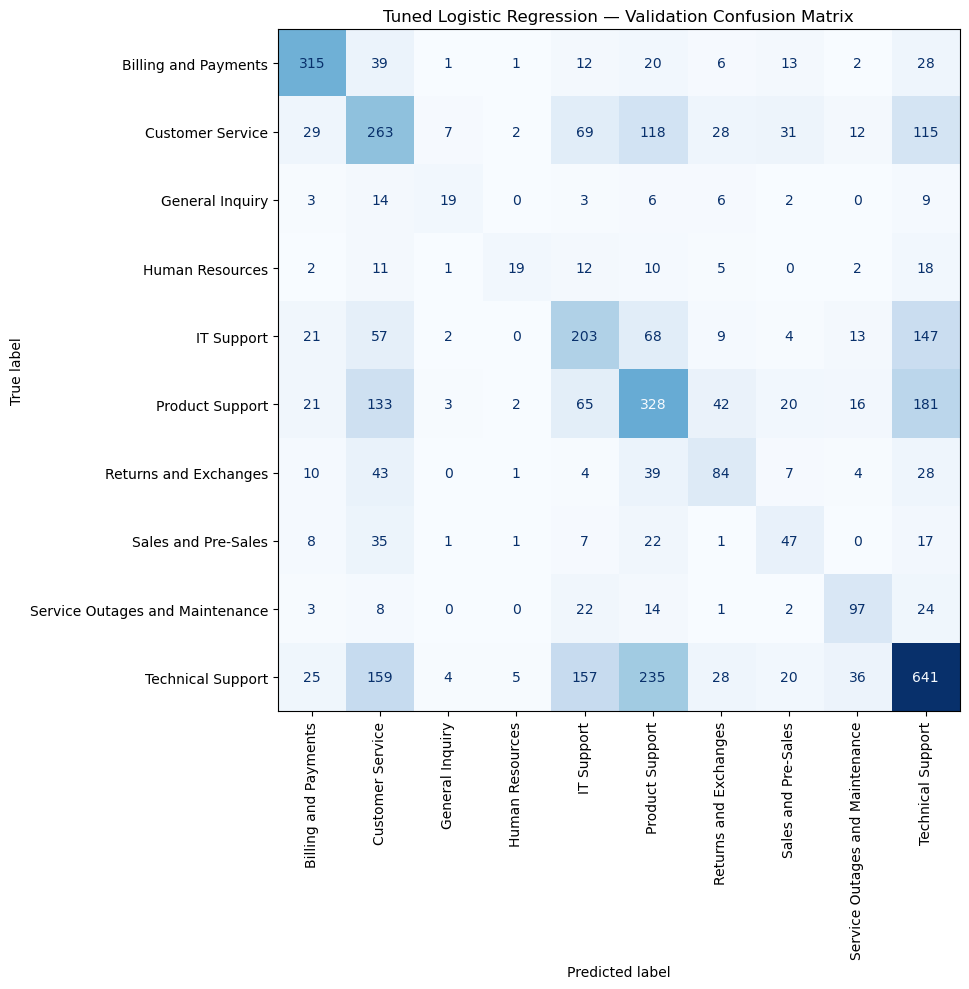

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_predictions = best_text_pipeline.predict(
    validation_df[text_column]
)

# Per-queue results for the tuned model.
best_queue_report = classification_report(
    y_validation,
    best_predictions,
    labels=QUEUE_LABELS,
    output_dict=True,
    zero_division=0
)

best_queue_results = (
    pd.DataFrame(best_queue_report).T
    .loc[QUEUE_LABELS, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score")
)

print("Tuned model — validation results by queue:")
display(best_queue_results.round(4))

# Per-language results.
best_validation_results = validation_df[
    ["ticket_id", "language", TARGET_COLUMN]
].copy()
best_validation_results["prediction"] = best_predictions

best_language_rows = []

for language, group in best_validation_results.groupby("language"):
    best_language_rows.append({
        "language": language,
        "tickets": len(group),
        "queues_present": group[TARGET_COLUMN].nunique(),
        "accuracy": accuracy_score(
            group[TARGET_COLUMN], group["prediction"]
        ),
        "macro_f1_10_queues": f1_score(
            group[TARGET_COLUMN],
            group["prediction"],
            labels=QUEUE_LABELS,
            average="macro",
            zero_division=0
        )
    })

best_language_results = pd.DataFrame(best_language_rows)
print("Tuned model — validation results by language:")
display(best_language_results.round(4))

# Rows are actual queues; columns are predicted queues.
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_predictions,
    labels=QUEUE_LABELS,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title("Tuned Logistic Regression — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [8]:
import joblib
import sklearn

report_dir = PROJECT_ROOT / "reports" / "model_development"
report_dir.mkdir(parents=True, exist_ok=True)

model_dir = PROJECT_ROOT / "data" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

# Save comparison tables and detailed validation results.
pd.DataFrame([
    benchmark_metrics,
    lr_metrics,
    text_only_metrics
]).to_csv(report_dir / "initial_comparison.csv", index=False)

tuning_results.to_csv(
    report_dir / "hyperparameter_comparison.csv", index=False
)
best_queue_results.to_csv(
    report_dir / "validation_by_queue.csv", index_label="queue"
)
best_language_results.to_csv(
    report_dir / "validation_by_language.csv", index=False
)

fig.savefig(
    report_dir / "validation_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

# Save the fitted notebook model locally.
joblib.dump(
    best_text_pipeline,
    model_dir / "text_logistic_regression.joblib"
)

# Save the selected model settings.
selected_model_config = {
    "algorithm": "LogisticRegression",
    "input_column": text_column,
    "selection_metric": "validation_macro_f1",
    "C": float(best_text_pipeline["classifier"].C),
    "class_weight": best_text_pipeline["classifier"].class_weight,
    "solver": "lbfgs",
    "max_iter": 2000,
    "random_state": 42,
    "tfidf": {
        "max_features": 30000,
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True
    },
    "sklearn_version": sklearn.__version__,
    "validation_results": tuning_results.iloc[0].to_dict(),
    "feature_datasets": feature_config["datasets"]
}

(report_dir / "selected_model.json").write_text(
    json.dumps(selected_model_config, indent=2),
    encoding="utf-8"
)

project_config["model_development"] = selected_model_config
config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Reports saved:", report_dir)
print("Notebook model saved:", model_dir)

Reports saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/model_development
Notebook model saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/data/models


### Notebook packages

Install the packages from `requirements-notebooks.txt` before running the project, then restart the kernel. See the setup steps in [README.md](README.md). Package installation is no longer part of the training steps.


In [10]:
import sys
import sagemaker
import sklearn
from sagemaker import image_uris

print("Python:", sys.version.split()[0])
print("SageMaker SDK:", sagemaker.__version__)
print("Scikit-learn:", sklearn.__version__)

# Inspect the image versions supported by the installed SDK.
image_config = image_uris.config_for_framework("sklearn")
image_versions = image_config.get(
    "versions",
    image_config.get("training", {}).get("versions", {})
)

print("Available scikit-learn image versions:", list(image_versions))

for version, details in image_versions.items():
    if version.startswith(("1.4", "1.9")):
        print(version, "Python options:", details.get("py_versions"))

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Python: 3.12.14
SageMaker SDK: 2.257.6
Scikit-learn: 1.7.2
Available scikit-learn image versions: ['0.20.0', '0.23-1', '1.0-1', '1.2-1', '1.4-2']
1.4-2 Python options: ['py3']


In [11]:
from importlib.metadata import version

TRAINING_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_training"
TRAINING_SOURCE_DIR.mkdir(parents=True, exist_ok=True)

# Match the notebook's ML packages in the training environment.
training_packages = [
    "scikit-learn",
    "numpy",
    "scipy",
    "pandas",
    "joblib",
    "threadpoolctl",
]

training_requirements = "\n".join(
    f"{package}=={version(package)}"
    for package in training_packages
) + "\n"

(TRAINING_SOURCE_DIR / "requirements.txt").write_text(
    training_requirements,
    encoding="utf-8"
)

# Include the selected settings and dataset fingerprints.
(TRAINING_SOURCE_DIR / "training_config.json").write_text(
    json.dumps(project_config["model_development"], indent=2),
    encoding="utf-8"
)

print("Training script folder:", TRAINING_SOURCE_DIR)
print("\nTraining package requirements:")
print(training_requirements)

Training script folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_training

Training package requirements:
scikit-learn==1.7.2
numpy==1.26.4
scipy==1.16.3
pandas==2.3.3
joblib==1.5.3
threadpoolctl==3.6.0



In [12]:
%%writefile src/ticket_training/train.py
import hashlib
import json
import os
from importlib.metadata import version
from pathlib import Path

import joblib
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline


def load_verified_data(directory, split_name, config):
    path = Path(directory) / f"{split_name}.csv"
    expected = config["feature_datasets"][split_name]

    fingerprint = hashlib.sha256(path.read_bytes()).hexdigest()
    if fingerprint != expected["sha256"]:
        raise ValueError(f"{split_name}: dataset fingerprint mismatch")

    df = pd.read_csv(
        path,
        dtype={"ticket_id": "string"},
        keep_default_na=False,
    )

    if len(df) != expected["rows"]:
        raise ValueError(f"{split_name}: unexpected row count")
    if not df["ticket_id"].is_unique:
        raise ValueError(f"{split_name}: duplicate ticket IDs")

    return df


def calculate_metrics(actual, predicted, labels):
    return {
        "accuracy": float(accuracy_score(actual, predicted)),
        "macro_f1": float(f1_score(
            actual, predicted,
            labels=labels, average="macro", zero_division=0,
        )),
        "weighted_f1": float(f1_score(
            actual, predicted,
            labels=labels, average="weighted", zero_division=0,
        )),
    }


def main():
    config_path = Path(__file__).with_name("training_config.json")
    config = json.loads(config_path.read_text(encoding="utf-8"))

    train = load_verified_data(
        os.environ["SM_CHANNEL_TRAIN"], "train", config
    )
    validation = load_verified_data(
        os.environ["SM_CHANNEL_VALIDATION"], "validation", config
    )

    if set(train["ticket_id"]) & set(validation["ticket_id"]):
        raise ValueError("Training and validation tickets overlap")

    text_column = config["input_column"]
    labels = sorted(train["queue"].unique())

    if len(labels) != 10:
        raise ValueError("Expected 10 training queues")
    if not set(validation["queue"]).issubset(labels):
        raise ValueError("Validation contains unknown queue labels")

    for name, df in [("train", train), ("validation", validation)]:
        if not df[text_column].str.strip().ne("").all():
            raise ValueError(f"{name}: empty ticket text")

    tfidf_settings = dict(config["tfidf"])
    tfidf_settings["ngram_range"] = tuple(
        tfidf_settings["ngram_range"]
    )

    model = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_settings)),
        ("classifier", LogisticRegression(
            C=config["C"],
            class_weight=config["class_weight"],
            solver=config["solver"],
            max_iter=config["max_iter"],
            random_state=config["random_state"],
        )),
    ])

    print(f"Training on {len(train):,} tickets.", flush=True)
    model.fit(train[text_column], train["queue"])

    predictions = model.predict(validation[text_column])
    metrics = calculate_metrics(
        validation["queue"], predictions, labels
    )

    benchmark = DummyClassifier(strategy="most_frequent")
    benchmark.fit(train[[text_column]], train["queue"])
    benchmark_predictions = benchmark.predict(
        validation[[text_column]]
    )
    benchmark_metrics = calculate_metrics(
        validation["queue"], benchmark_predictions, labels
    )

    model_dir = Path(os.environ["SM_MODEL_DIR"])
    output_dir = Path(os.environ["SM_OUTPUT_DATA_DIR"])
    model_dir.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(model, model_dir / "model.joblib")

    report = {
        "evaluation_split": "validation",
        "model": metrics,
        "benchmark": benchmark_metrics,
        "training_rows": len(train),
        "validation_rows": len(validation),
        "solver_iterations": int(
            model["classifier"].n_iter_.max()
        ),
    }
    (output_dir / "evaluation.json").write_text(
        json.dumps(report, indent=2), encoding="utf-8"
    )

    queue_report = classification_report(
        validation["queue"], predictions,
        labels=labels, output_dict=True, zero_division=0,
    )
    pd.DataFrame(queue_report).T.to_csv(
        output_dir / "validation_by_queue.csv",
        index_label="queue",
    )

    language_rows = []
    evaluation_rows = validation[["language", "queue"]].copy()
    evaluation_rows["prediction"] = predictions

    for language, group in evaluation_rows.groupby("language"):
        language_rows.append({
            "language": language,
            "tickets": len(group),
            "queues_present": group["queue"].nunique(),
            **calculate_metrics(
                group["queue"], group["prediction"], labels
            ),
        })

    pd.DataFrame(language_rows).to_csv(
        output_dir / "validation_by_language.csv", index=False
    )

    pd.DataFrame(
        confusion_matrix(
            validation["queue"], predictions, labels=labels
        ),
        index=labels,
        columns=labels,
    ).to_csv(
        output_dir / "validation_confusion_matrix.csv",
        index_label="actual_queue",
    )

    metadata = {
        "configuration": config,
        "queue_labels": labels,
        "packages": {
            name: version(name)
            for name in [
                "scikit-learn", "numpy", "scipy",
                "pandas", "joblib", "threadpoolctl",
            ]
        },
    }
    (model_dir / "model_metadata.json").write_text(
        json.dumps(metadata, indent=2), encoding="utf-8"
    )

    for metric_name, value in metrics.items():
        print(f"validation:{metric_name}={value:.8f}", flush=True)

    print("Model and validation reports saved.", flush=True)


if __name__ == "__main__":
    main()

Writing src/ticket_training/train.py


In [13]:
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.inputs import TrainingInput

# Check the script's Python syntax without running training.
script_path = TRAINING_SOURCE_DIR / "train.py"
compile(
    script_path.read_text(encoding="utf-8"),
    str(script_path),
    "exec"
)

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

sagemaker_session = sagemaker.Session(
    boto_session=aws_session,
    default_bucket=PROJECT_BUCKET
)

# Get the regional repository, then select the Python 3.12 image.
base_image_uri = image_uris.retrieve(
    framework="sklearn",
    region=AWS_REGION,
    version="1.4-2",
    py_version="py3",
    instance_type="ml.m5.xlarge",
    image_scope="training"
)

TRAINING_IMAGE_URI = (
    base_image_uri.rsplit(":", 1)[0]
    + ":1.4-2-py312-cpu-py3"
)

training_estimator = SKLearn(
    entry_point="train.py",
    source_dir=str(TRAINING_SOURCE_DIR),
    framework_version="1.4-2",
    py_version="py3",
    image_uri=TRAINING_IMAGE_URI,
    role=project_config["feature_store"]["execution_role_arn"],
    instance_count=1,
    instance_type="ml.m5.xlarge",
    volume_size=20,
    max_run=900,
    output_path=f"s3://{PROJECT_BUCKET}/training-output/",
    code_location=f"s3://{PROJECT_BUCKET}/training-code/",
    sagemaker_session=sagemaker_session,
    disable_profiler=True,
    debugger_hook_config=False,
    metric_definitions=[
        {
            "Name": f"validation:{metric}",
            "Regex": rf"validation:{metric}=([0-9.]+)"
        }
        for metric in ["accuracy", "macro_f1", "weighted_f1"]
    ]
)

training_inputs = {
    name: TrainingInput(
        s3_data=feature_config["datasets"][name]["uri"],
        content_type="text/csv",
        input_mode="File"
    )
    for name in ["train", "validation"]
}

print("Training image:", TRAINING_IMAGE_URI)
print("Compute: one ml.m5.xlarge instance")
print("Maximum training runtime: 15 minutes")

/opt/conda/lib/python3.12/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: SKLearn is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
SKLearn is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Training image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-py312-cpu-py3
Compute: one ml.m5.xlarge instance
Maximum training runtime: 15 minutes


In [14]:
from datetime import datetime, timezone

# Prevent accidentally launching another job by rerunning this cell.
if project_config.get("managed_training", {}).get("job_name"):
    raise RuntimeError(
        "A training job is already recorded. Check its status "
        "before launching another one."
    )

training_job_name = (
    "aai540-group3-lr-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

# Save the job name before starting training.
project_config["managed_training"] = {
    "job_name": training_job_name,
    "image_uri": TRAINING_IMAGE_URI,
    "instance_type": "ml.m5.xlarge",
    "sdk_version": sagemaker.__version__,
    "source_sha256": {
        filename: hashlib.sha256(
            (TRAINING_SOURCE_DIR / filename).read_bytes()
        ).hexdigest()
        for filename in [
            "train.py", "requirements.txt", "training_config.json"
        ]
    }
}

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

training_estimator.fit(
    inputs=training_inputs,
    job_name=training_job_name,
    wait=False
)

sagemaker_client = aws_session.client("sagemaker")
job_details = sagemaker_client.describe_training_job(
    TrainingJobName=training_job_name
)

print("Job name:", training_job_name)
print("Status:", job_details["TrainingJobStatus"])
print("Stage:", job_details.get("SecondaryStatus"))

INFO:sagemaker:Creating training-job with name: aai540-group3-lr-20261004-003353


Job name: aai540-group3-lr-20261004-003353
Status: InProgress
Stage: Starting


In [15]:
training_job_name = project_config["managed_training"]["job_name"]

job_details = aws_session.client("sagemaker").describe_training_job(
    TrainingJobName=training_job_name
)

status = job_details["TrainingJobStatus"]

print("Job:", training_job_name)
print("Current status:", status)
print("Current stage:", job_details.get("SecondaryStatus"))

if status == "Completed":
    print("Training seconds:", job_details.get("TrainingTimeInSeconds"))
    print("Model location:", job_details["ModelArtifacts"]["S3ModelArtifacts"])

    for metric in job_details.get("FinalMetricDataList", []):
        print(f"{metric['MetricName']}: {metric['Value']:.4f}")

elif status == "Failed":
    print("Failure reason:", job_details.get("FailureReason"))

else:
    transitions = job_details.get("SecondaryStatusTransitions", [])
    if transitions:
        print("Latest update:", transitions[-1].get("StatusMessage"))

Job: aai540-group3-lr-20261004-003353
Current status: Completed
Current stage: Completed
Training seconds: 119
Model location: s3://aai540-group3-tickets-390568313988-us-east-1/training-output/aai540-group3-lr-20261004-003353/output/model.tar.gz
validation:weighted_f1: 0.4569
validation:macro_f1: 0.4362
validation:accuracy: 0.4557


In [16]:
import tarfile

model_uri = job_details["ModelArtifacts"]["S3ModelArtifacts"]
output_uri = model_uri.rsplit("/", 1)[0] + "/output.tar.gz"

def read_s3_archive(uri):
    location = urlparse(uri)
    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/")
    )
    try:
        return response["Body"].read(), response.get("VersionId")
    finally:
        response["Body"].close()

def read_archive_member(archive_bytes, filename):
    # Read only the requested file, without extracting the archive.
    with tarfile.open(fileobj=BytesIO(archive_bytes), mode="r:gz") as archive:
        matches = [
            member for member in archive.getmembers()
            if member.isfile() and Path(member.name).name == filename
        ]
        if len(matches) != 1:
            raise ValueError(f"Expected exactly one {filename} in archive")
        with archive.extractfile(matches[0]) as member_file:
            return member_file.read()

managed_model_archive, model_version = read_s3_archive(model_uri)
managed_output_archive, output_version = read_s3_archive(output_uri)

managed_evaluation = json.loads(
    read_archive_member(managed_output_archive, "evaluation.json")
)
managed_metadata = json.loads(
    read_archive_member(managed_model_archive, "model_metadata.json")
)

# Save the SageMaker training reports.
managed_report_dir = PROJECT_ROOT / "reports" / "managed_training"
managed_report_dir.mkdir(parents=True, exist_ok=True)

for filename, contents in [
    ("evaluation.json", managed_evaluation),
    ("model_metadata.json", managed_metadata),
]:
    (managed_report_dir / filename).write_text(
        json.dumps(contents, indent=2),
        encoding="utf-8"
    )

project_config["managed_training"].update({
    "status": job_details["TrainingJobStatus"],
    "model_uri": model_uri,
    "model_version_id": model_version,
    "output_uri": output_uri,
    "output_version_id": output_version,
    "training_seconds": job_details["TrainingTimeInSeconds"],
    "validation_metrics": managed_evaluation["model"],
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Managed training evaluation:")
print(json.dumps(managed_evaluation, indent=2))
print("\nPackages used by the training job:")
print(json.dumps(managed_metadata["packages"], indent=2))

Managed training evaluation:
{
  "evaluation_split": "validation",
  "model": {
    "accuracy": 0.45573622402890696,
    "macro_f1": 0.43616079833313764,
    "weighted_f1": 0.4569255989374723
  },
  "benchmark": {
    "accuracy": 0.2958446251129178,
    "macro_f1": 0.04566050888811433,
    "weighted_f1": 0.13508416134469234
  },
  "training_rows": 17710,
  "validation_rows": 4428,
  "solver_iterations": 229
}

Packages used by the training job:
{
  "scikit-learn": "1.7.2",
  "numpy": "1.26.4",
  "scipy": "1.16.3",
  "pandas": "2.3.3",
  "joblib": "1.5.3",
  "threadpoolctl": "3.6.0"
}



In [17]:
# Load the model produced by our completed AWS training job.
managed_model = joblib.load(BytesIO(
    read_archive_member(managed_model_archive, "model.joblib")
))

assert managed_metadata["configuration"] == (
    project_config["model_development"]
)

# Record the selected model before examining test performance.
project_config["final_model"] = {
    "training_job_name": project_config["managed_training"]["job_name"],
    "model_uri": model_uri,
    "model_version_id": model_version,
    "model_archive_sha256": hashlib.sha256(
        managed_model_archive
    ).hexdigest(),
    "selection_metric": "validation_macro_f1",
}

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

# Load the exact reserved test-file version.
test_info = project_config["s3_data"]["test"]
test_location = urlparse(test_info["uri"])

response = s3_client.get_object(
    Bucket=test_location.netloc,
    Key=test_location.path.lstrip("/"),
    VersionId=test_info["version_id"]
)
try:
    test_df = pd.read_csv(
        response["Body"],
        dtype={"ticket_id": "string"},
        low_memory=False
    )
finally:
    response["Body"].close()

assert len(test_df) == 4428
assert test_df["ticket_id"].is_unique
assert not set(test_df["ticket_id"]) & set(train_df["ticket_id"])
assert not set(test_df["ticket_id"]) & set(validation_df["ticket_id"])

# Apply the same text preparation used for training.
test_text = (
    test_df["subject"].fillna("").astype(str).str.strip()
    + " "
    + test_df["body"].fillna("").astype(str).str.strip()
).str.strip()

assert test_text.str.len().gt(0).all()

test_predictions = managed_model.predict(test_text)
y_test = test_df[TARGET_COLUMN]

# The benchmark queue is determined only from training labels.
majority_queue = y_train.value_counts().idxmax()
test_benchmark_predictions = [majority_queue] * len(test_df)

test_metric_rows = []

for name, predictions in [
    ("Majority-class benchmark", test_benchmark_predictions),
    ("Managed Logistic Regression", test_predictions),
]:
    test_metric_rows.append({
        "model": name,
        "evaluation_split": "test",
        "accuracy": accuracy_score(y_test, predictions),
        "macro_f1": f1_score(
            y_test, predictions,
            labels=QUEUE_LABELS, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_test, predictions,
            labels=QUEUE_LABELS, average="weighted", zero_division=0
        )
    })

test_metrics = pd.DataFrame(test_metric_rows)

print("Test tickets evaluated:", len(test_df))
display(test_metrics.round(4))

Test tickets evaluated: 4428


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,test,0.2956,0.0456,0.1349
1,Managed Logistic Regression,test,0.4634,0.4464,0.4653


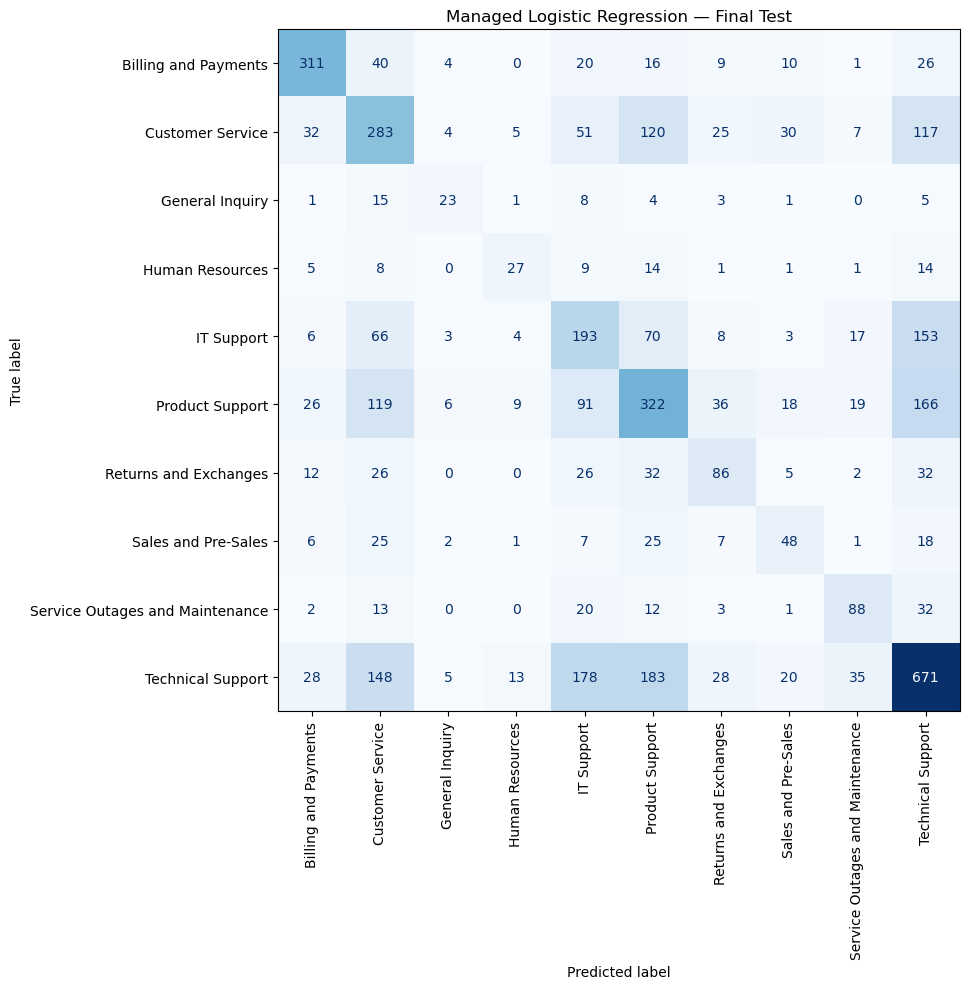

Final test reports saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/final_test


,language,tickets,queues_present,accuracy,macro_f1_10_queues
0,de,1720,10,0.4023,0.3410
1,en,2555,10,0.5029,0.5148
2,es,82,10,0.5000,0.3837
3,fr,39,9,0.5128,0.3591
4,pt,32,8,0.4375,0.3738


In [18]:
test_report_dir = PROJECT_ROOT / "reports" / "final_test"
test_report_dir.mkdir(parents=True, exist_ok=True)

test_metrics.to_csv(
    test_report_dir / "metrics.csv", index=False
)

# Results by queue.
test_queue_report = classification_report(
    y_test,
    test_predictions,
    labels=QUEUE_LABELS,
    output_dict=True,
    zero_division=0
)

test_queue_results = (
    pd.DataFrame(test_queue_report).T
    .loc[QUEUE_LABELS, ["precision", "recall", "f1-score", "support"]]
)

test_queue_results.to_csv(
    test_report_dir / "by_queue.csv", index_label="queue"
)

# Results by language.
test_results = test_df[
    ["ticket_id", "language", TARGET_COLUMN]
].copy()
test_results["prediction"] = test_predictions

test_language_rows = []

for language, group in test_results.groupby("language"):
    test_language_rows.append({
        "language": language,
        "tickets": len(group),
        "queues_present": group[TARGET_COLUMN].nunique(),
        "accuracy": accuracy_score(
            group[TARGET_COLUMN], group["prediction"]
        ),
        "macro_f1_10_queues": f1_score(
            group[TARGET_COLUMN],
            group["prediction"],
            labels=QUEUE_LABELS,
            average="macro",
            zero_division=0
        )
    })

test_language_results = pd.DataFrame(test_language_rows)
test_language_results.to_csv(
    test_report_dir / "by_language.csv", index=False
)

# Save the final test confusion matrix.
test_fig, test_ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=QUEUE_LABELS,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=test_ax
)

test_ax.set_title("Managed Logistic Regression — Final Test")
test_fig.tight_layout()
test_fig.savefig(
    test_report_dir / "confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# Preserve individual predictions locally for later analysis.
prediction_dir = PROJECT_ROOT / "data" / "predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
test_results.to_csv(prediction_dir / "test_predictions.csv", index=False)

project_config["final_model"].update({
    "test_dataset": test_info,
    "test_rows": len(test_df),
    "test_metrics": test_metric_rows[1],
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Final test reports saved:", test_report_dir)
display(test_language_results.round(4))